[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/23_features_selection.ipynb)



# La sélection de variables

Toutes les variables ne se valent pas. Certaines portent l'information utile,
d'autres n'apportent que du bruit ou répètent ce que d'autres disent déjà. La sélection de variables consiste à trouver et garder les plus utiles.

Pourquoi s'en soucier ? Moins de variables, c'est un modèle plus rapide, plus
simple à interpréter, et souvent plus robuste le surapprentissage du notebook 21
diminue quand on retire les variables inutiles.

## Le plan

| Section | La méthode | Principe |
|---|---|---|
| 1 | VarianceThreshold | retirer ce qui ne varie pas |
| 2 | SelectKBest | garder les k plus corrélées à la cible |
| 3 | SelectFromModel | laisser un modèle juger |
| 4 | RFE et RFECV | éliminer une à une |

## Deux pièges annoncés

`VarianceThreshold` ne regarde que les variables, jamais la cible il peut
retirer une variable peu variable mais très prédictive.

Et `grid_scores_` de RFECV a été remplacé par `cv_results_['mean_test_score']`
dans les versions récentes.

Prérequis : les notebooks 20 à 22.

## 1. VarianceThreshold : retirer ce qui ne varie pas

L'idée la plus simple : une variable qui ne change presque pas d'un individu à
l'autre n'apporte rien. Une colonne constante est inutile.

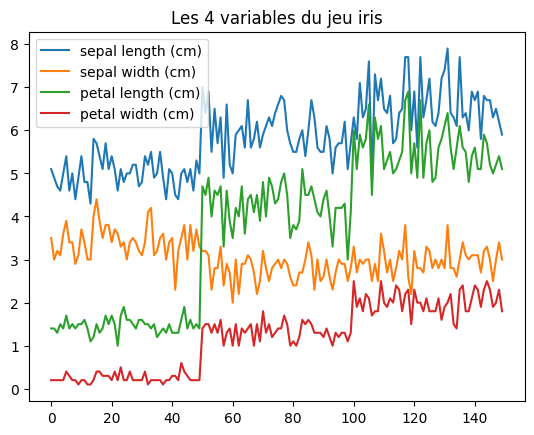

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.feature_selection import VarianceThreshold

iris = load_iris()
x = iris.data
y = iris.target

plt.plot(x)
plt.legend(iris.feature_names)
plt.title('Les 4 variables du jeu iris')
plt.show()

On voit que les variables n'ont pas la même amplitude. Mesurons leur variance.

In [2]:
print('variance de chaque colonne :')
for nom, v in zip(iris.feature_names, x.var(axis=0)):
    print(f'{nom:<20} {v:.3f}')

variance de chaque colonne :
sepal length (cm)    0.681
sepal width (cm)     0.189
petal length (cm)    3.096
petal width (cm)     0.577


Attention à `axis=0` : on veut la variance par colonne, une par variable. Sans
axis, `x.var()` donnerait une seule valeur pour tout le tableau le piège du
notebook 12.

La `petal length` varie beaucoup (3,1), la `sepal width` peu (0,19).

### Appliquer le seuil

In [3]:
selector = VarianceThreshold(threshold=0.2)
selector.fit_transform(x)

print('variables gardées :', selector.get_support())
print(np.array(iris.feature_names)[selector.get_support()])

variables gardées : [ True False  True  True]
['sepal length (cm)' 'petal length (cm)' 'petal width (cm)']


`get_support()` renvoie un masque booléen : `True` pour les variables gardées. Avec
un seuil de 0,2, la `sepal width` (variance 0,19) est retirée elle ne varie pas
assez.

On passe ce masque entre crochets pour retrouver les noms, du fancy indexing du
notebook 11.

### Le piège : la variance ignore la cible

C'est la limite majeure de cette méthode. `VarianceThreshold` ne regarde que
les variables, jamais `y`. Il peut donc retirer une variable peu variable mais
très prédictive.

Une variable peut avoir une petite variance et pourtant séparer parfaitement les
classes. La variance ne mesure pas l'utilité, seulement l'étalement.

`VarianceThreshold` sert donc surtout à un premier nettoyage retirer les
colonnes quasi constantes pas à choisir les meilleures variables. Pour ça, il
faut regarder le lien avec la cible, ce que font les méthodes suivantes.

## 2. SelectKBest : les k plus liées à la cible

`SelectKBest` garde les `k` variables les plus corrélées à la cible, selon un
test statistique.

In [4]:
from sklearn.feature_selection import SelectKBest, chi2

scores, p_values = chi2(x, y)

print('score chi² de chaque variable :')
for nom, s in zip(iris.feature_names, scores):
    print(f'  {nom:<20} {s:.2f}')

score chi² de chaque variable :
  sepal length (cm)    10.82
  sepal width (cm)     3.71
  petal length (cm)    116.31
  petal width (cm)     67.05


Le test du chi² mesure le lien entre chaque variable et la cible. Plus le score
est élevé, plus la variable est liée à ce qu'on veut prédire.

Ici les deux variables de pétale ont des scores écrasants (116 et 67) contre
les sépales (11 et 4). Les pétales sont bien plus prédictives.

In [5]:
selector = SelectKBest(chi2, k=2)
selector.fit_transform(x, y)

print('les 2 meilleures :', np.array(iris.feature_names)[selector.get_support()])

les 2 meilleures : ['petal length (cm)' 'petal width (cm)']


`SelectKBest` garde les 2 meilleures : les deux variables de pétale.

C'est exactement ce qu'on avait vu à l'œil au notebook 19, avec le `pairplot` :
les pétales séparaient nettement les trois espèces, les sépales se chevauchaient.
La sélection statistique confirme l'intuition visuelle.

La différence avec VarianceThreshold. SelectKBest regarde le lien avec `y`,
donc il mesure l'utilité pour la prédiction, pas juste l'étalement. C'est une
sélection bien plus pertinente.

Le `chi2` convient aux variables positives. Pour d'autres cas, sklearn propose
`f_classif` (classification) et `f_regression` (régression), qu'on passe à la
place de `chi2`.

## 3. SelectFromModel : laisser un modèle juger

Cette méthode entraîne un modèle, puis garde les variables auxquelles il accorde
le plus de poids.

In [6]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import SGDClassifier

selector = SelectFromModel(SGDClassifier(random_state=0), threshold='mean')
selector.fit_transform(x, y)

print('variables gardées :', np.array(iris.feature_names)[selector.get_support()])

variables gardées : ['petal length (cm)' 'petal width (cm)']


`SelectFromModel` entraîne le `SGDClassifier`, regarde ses coefficients, et garde
les variables dont le poids dépasse un seuil ici la moyenne des poids.

Une variable avec un grand coefficient pèse lourd dans la décision du modèle ;
c'est donc qu'elle est importante.

In [7]:
# Voir les coefficients appris
print('forme des coefficients :', selector.estimator_.coef_.shape)
print()
print('poids moyen par variable :')
poids = np.abs(selector.estimator_.coef_).mean(axis=0)
for nom, p in zip(iris.feature_names, poids):
    print(f'  {nom:<20} {p:.3f}')

forme des coefficients : (3, 4)

poids moyen par variable :
  sepal length (cm)    31.803
  sepal width (cm)     53.752
  petal length (cm)    64.556
  petal width (cm)     67.759


`estimator_` est le modèle entraîné à l'intérieur du sélecteur le tiret bas final
signale qu'il a été calculé pendant `fit`, comme au notebook 09.

Les coefficients ont la forme `(3, 4)` : 3 classes, 4 variables. On prend la
moyenne des valeurs absolues par colonne (`axis=0`) pour obtenir un poids par
variable.

L'intérêt de cette méthode. Elle tient compte des variables ensemble, pas
une par une. Si deux variables sont redondantes, le modèle peut n'en garder qu'une ce que `SelectKBest`, qui juge chaque variable isolément, ne fait pas.

Sa limite. Le résultat dépend du modèle choisi et de son entraînement. Un
`SGDClassifier` sensible à l'échelle donnera des poids trompeurs si les données ne
sont pas normalisées d'où l'intérêt de le mettre dans un pipeline avec un scaler.

## 4. RFE et RFECV : éliminer une à une

La méthode la plus élaborée. RFE *Recursive Feature Elimination* retire les
variables une par une, en éliminant à chaque tour la moins utile, jusqu'à
n'en garder que le nombre voulu.

In [8]:
from sklearn.feature_selection import RFE, RFECV

selector = RFE(SGDClassifier(random_state=0), n_features_to_select=2, step=1)
selector.fit(x, y)

print('classement des variables :', selector.ranking_)
print('gardées :', np.array(iris.feature_names)[selector.get_support()])

classement des variables : [3 1 2 1]
gardées : ['sepal width (cm)' 'petal width (cm)']


`ranking_` classe les variables : 1 pour les gardées, puis 2, 3... dans l'ordre
d'élimination. Les variables classées 1 sont les survivantes.

Le `step=1` retire une variable à chaque tour. Sur beaucoup de variables, on peut
en retirer plusieurs à la fois pour aller plus vite.

### RFECV : choisir automatiquement le nombre

Le problème de RFE : il faut décider combien de variables garder. RFECV le
détermine automatiquement par validation croisée.

In [9]:
selector = RFECV(SGDClassifier(random_state=0), step=1,
                 min_features_to_select=2, cv=5)
selector.fit(x, y)

print('nombre optimal de variables :', selector.n_features_)
print('classement :', selector.ranking_)

nombre optimal de variables : 3
classement : [2 1 1 1]


RFECV teste chaque nombre de variables et mesure le score par validation croisée.
Il garde le nombre qui maximise ce score ici déterminé automatiquement, sans
qu'on ait à le fixer.

### Le piège : grid_scores_ n'existe plus

In [10]:
try:
    selector.grid_scores_
except AttributeError as e:
    print('AttributeError :', str(e)[:70])

AttributeError : 'RFECV' object has no attribute 'grid_scores_'


`grid_scores_` (et `grid_score_` au singulier, qui n'a jamais existé) a été
retiré des versions récentes. Il est remplacé par `cv_results_`, un
dictionnaire.

In [11]:
print('clés disponibles :', list(selector.cv_results_.keys())[:3], '...')
scores = selector.cv_results_['mean_test_score']
print('scores par nombre de variables :', scores.round(3))

clés disponibles : ['mean_test_score', 'std_test_score', 'split0_test_score'] ...
scores par nombre de variables : [0.8   0.847 0.773]


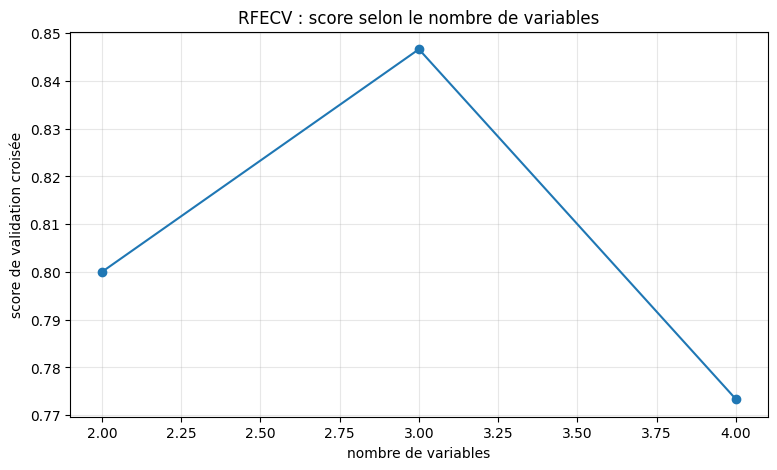

In [12]:
plt.figure(figsize=(9, 5))
plt.plot(range(2, len(scores) + 2), scores, marker='o')
plt.xlabel('nombre de variables')
plt.ylabel('score de validation croisée')
plt.title('RFECV : score selon le nombre de variables')
plt.grid(alpha=0.3)
plt.show()

La courbe montre le score selon le nombre de variables gardées. Le sommet indique
le nombre optimal : au-delà, ajouter des variables n'aide plus, voire nuit.

C'est la même logique que la courbe de validation du notebook 21, appliquée cette
fois au nombre de variables plutôt qu'à un hyperparamètre. Trop peu de
variables : sous-apprentissage. Trop : du bruit qui dégrade.

RFECV est la méthode la plus complète : elle tient compte des variables
ensemble (comme SelectFromModel), et choisit leur nombre automatiquement (contrairement
à RFE et SelectKBest). Son coût est la lenteur elle réentraîne le modèle de
nombreuses fois.

## 5. Comparer les méthodes

Sur iris, voyons si les quatre méthodes s'accordent.

In [13]:
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, SelectFromModel, RFE

methodes = {
    'VarianceThreshold': VarianceThreshold(threshold=0.2),
    'SelectKBest': SelectKBest(chi2, k=2),
    'SelectFromModel': SelectFromModel(SGDClassifier(random_state=0), threshold='mean'),
    'RFE': RFE(SGDClassifier(random_state=0), n_features_to_select=2),
}

for nom, sel in methodes.items():
    sel.fit(x, y)
    gardees = np.array(iris.feature_names)[sel.get_support()]
    print(f'{nom:<18} : {list(gardees)}')

VarianceThreshold  : [np.str_('sepal length (cm)'), np.str_('petal length (cm)'), np.str_('petal width (cm)')]
SelectKBest        : [np.str_('petal length (cm)'), np.str_('petal width (cm)')]
SelectFromModel    : [np.str_('petal length (cm)'), np.str_('petal width (cm)')]
RFE                : [np.str_('sepal width (cm)'), np.str_('petal width (cm)')]


Les méthodes qui regardent la cible convergent vers les deux variables de pétale celles qui séparent le mieux les espèces, comme le montrait le
`pairplot` du notebook 19.

`VarianceThreshold` diffère, car il ignore la cible : il garde ce qui varie, pas
ce qui prédit. C'est le rappel de sa limite.

Le message. Quand plusieurs méthodes indépendantes désignent les mêmes
variables, on peut leur faire confiance. Ici, statistique (chi²), poids de modèle
et élimination récursive s'accordent : les pétales portent l'information.

## 6. Mémo

### Les méthodes

| Méthode | Regarde la cible ? | Variables ensemble ? |
|---|---|---|
| `VarianceThreshold` | non | non |
| `SelectKBest` | oui | non (une par une) |
| `SelectFromModel` | oui | oui |
| `RFE` | oui | oui |
| `RFECV` | oui | oui, + choisit le nombre |

### La syntaxe commune

```python
selector = Methode(...)
selector.fit_transform(x, y)
selector.get_support() # masque booléen
np.array(noms)[selector.get_support()] # noms gardés
```

### Récupérer les scores de RFECV

```python
selector.cv_results_['mean_test_score'] # Pas grid_scores_
selector.n_features_ # nombre optimal
```

### Les pièges

| Situation | Ce qui se passe |
|---|---|
| `x.var()` sans axis | une seule valeur, pas une par colonne |
| `VarianceThreshold` seul | ignore la cible, rate les variables utiles |
| `grid_scores_` | retiré, utiliser `cv_results_` |
| Sélection avant validation croisée | fuite, à mettre dans un pipeline |
| SelectFromModel sans normaliser | poids trompeurs |

## 7. Exercices

**Exercice 1**

Sur iris, applique `SelectKBest` avec k allant de 1 à 4. Pour chaque k, entraîne
un `KNeighborsClassifier` sur les variables retenues et mesure le score en
validation croisée. Combien de variables suffisent ? Ajouter les sépales
aide-t-il ?

**Exercice 2**

Mets `SelectKBest` dans un pipeline avec un `SGDClassifier`, puis règle le `k` par
`GridSearchCV`. Pourquoi la sélection de variables doit-elle être dans le pipeline
et non faite avant ? Relie à la fuite d'information des notebooks précédents.

**Exercice 3**

Ce code sélectionne des variables puis évalue :

```python
selector = SelectKBest(chi2, k=2)
x_selected = selector.fit_transform(x, y) # sur tout x, y
scores = cross_val_score(SGDClassifier(), x_selected, y, cv=5)
```

Il contient une fuite. Explique où elle se cache c'est subtil, car la sélection
utilise `y` pourquoi cela gonfle le score, puis corrige avec un pipeline.

## Pour continuer

Tu sais maintenant réduire un jeu de variables à l'essentiel plus rapide, plus
simple, souvent plus robuste. La sélection de variables complète le prétraitement :
après avoir nettoyé et transformé, on garde ce qui compte.

Les notebooks suivants exploreront l'apprentissage non supervisé, où il n'y a plus
de cible `y`, et les modèles d'ensemble, qui combinent plusieurs modèles. Le
pipeline restera l'ossature qui garantit des évaluations honnêtes.

In [14]:
# Exercice 1

In [15]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

x, y = load_iris(return_X_y=True)

print('k | score validation croisée')
print('-' * 30)
for k in [1, 2, 3, 4]:
    x_selected = SelectKBest(chi2, k=k).fit_transform(x, y)
    score = cross_val_score(KNeighborsClassifier(), x_selected, y, cv=5).mean()
    print(f'{k} | {score:.4f}')

k | score validation croisée
------------------------------
1 | 0.9400
2 | 0.9667
3 | 0.9667
4 | 0.9733


In [16]:
# Exercice 2

In [17]:
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

pipeline = make_pipeline(
    SelectKBest(chi2),
    SGDClassifier(random_state=0))

params = {
    'selectkbest__k': [1, 2, 3, 4],
}

grid = GridSearchCV(pipeline, param_grid=params, cv=5)
grid.fit(x, y)

print('meilleur k :', grid.best_params_)
print('meilleur score :', round(grid.best_score_, 4))

meilleur k : {'selectkbest__k': 2}
meilleur score : 0.82


In [18]:
# À chaque pli de validation croisée :
# 1. SelectKBest regarde le y du TRAIN seulement -> choisit les variables
# 2. Le modèle s'entraîne sur ces variables
# 3. Le pli de validation est évalué avec ces variables, sans y avoir contribué

In [19]:
# Exercice 3

In [20]:
selector = SelectKBest(chi2, k=2)
x_selected = selector.fit_transform(x, y) # sur tout x, y
scores = cross_val_score(SGDClassifier(), x_selected, y, cv=5)

In [21]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score

pipeline = make_pipeline(
    SelectKBest(chi2, k=2),
    SGDClassifier(random_state=0))

scores = cross_val_score(pipeline, x, y, cv=5)

print('scores :', scores.round(3))
print('moyenne:', scores.mean().round(4))

scores : [0.767 0.833 0.7   0.833 0.967]
moyenne: 0.82
